# Fase 1: Análisis de Ocupación y Deduplicación Wi-Fi
**Objetivo:** Demostrar la diferencia entre las conexiones Wi-Fi brutas (que sobreestiman la ocupación por el uso de múltiples dispositivos) y la cantidad real de personas físicas en el campus de la UPF.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

print("Cargando el dataset... (Esto puede tardar unos segundos)")
# Cargamos el archivo CSV. low_memory=False ayuda con archivos muy grandes
df = pd.read_csv('../data/Conexiones_WiFi_Campus.csv', low_memory=False)

# Convertimos la columna Timestamp a formato de fecha de alta precisión (datetime)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M')

print(f"¡Dataset cargado con éxito! Filas totales: {len(df)}")
# Mostramos las primeras 5 filas para comprobar que todo está bien
df.head()

Cargando el dataset... (Esto puede tardar unos segundos)
¡Dataset cargado con éxito! Filas totales: 14320990


,Timestamp,ID_Universidad,MAC_Dispositivo,Punto_Acceso
0,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,FIJO_MAC_1,AP_Placa
1,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,FIJO_MAC_4,AP_Biblioteca
2,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,FIJO_MAC_6,AP_Clases
3,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,FIJO_MAC_7,AP_Clases
4,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,FIJO_MAC_17,AP_Clases


### Limpieza y Agrupación de Datos
Vamos a aislar una semana lectiva normal (ej. mediados de enero). Luego, agruparemos los datos hora a hora para comparar dos métricas:
1. **Total de Conexiones:** Lo que leería un router comercial (ruido + múltiples aparatos).
2. **Personas Reales:** Filtrando las direcciones MAC y agrupándolas por el ID del alumno (NIA), ignorando además los equipos fijos de la universidad.

In [21]:
# Aislamos una semana normal de enero
fecha_inicio = pd.to_datetime('2024-01-15 00:00:00')
fecha_fin = pd.to_datetime('2024-01-21 23:59:59')
df_semana = df[(df['Timestamp'] >= fecha_inicio) & (df['Timestamp'] <= fecha_fin)]

# Agrupamos por hora exacta y calculamos las métricas
resumen_horario = df_semana.resample('1h', on='Timestamp').agg(
    # Cuenta direcciones MAC únicas (la medición falsa/elevada)
    Total_Dispositivos=('MAC_Dispositivo', 'nunique'),
    
    # Cuenta IDs de universidad únicos, ignorando impresoras/PCs fijos (la verdad)
    Personas_Reales=('ID_Universidad', lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique())
).reset_index()

print("Datos agrupados listos para graficar.")
resumen_horario.head()

Datos agrupados listos para graficar.


,Timestamp,Total_Dispositivos,Personas_Reales
0,2024-01-15 00:00:00,64,0
1,2024-01-15 01:00:00,64,0
2,2024-01-15 02:00:00,64,0
3,2024-01-15 03:00:00,64,0
4,2024-01-15 04:00:00,64,0


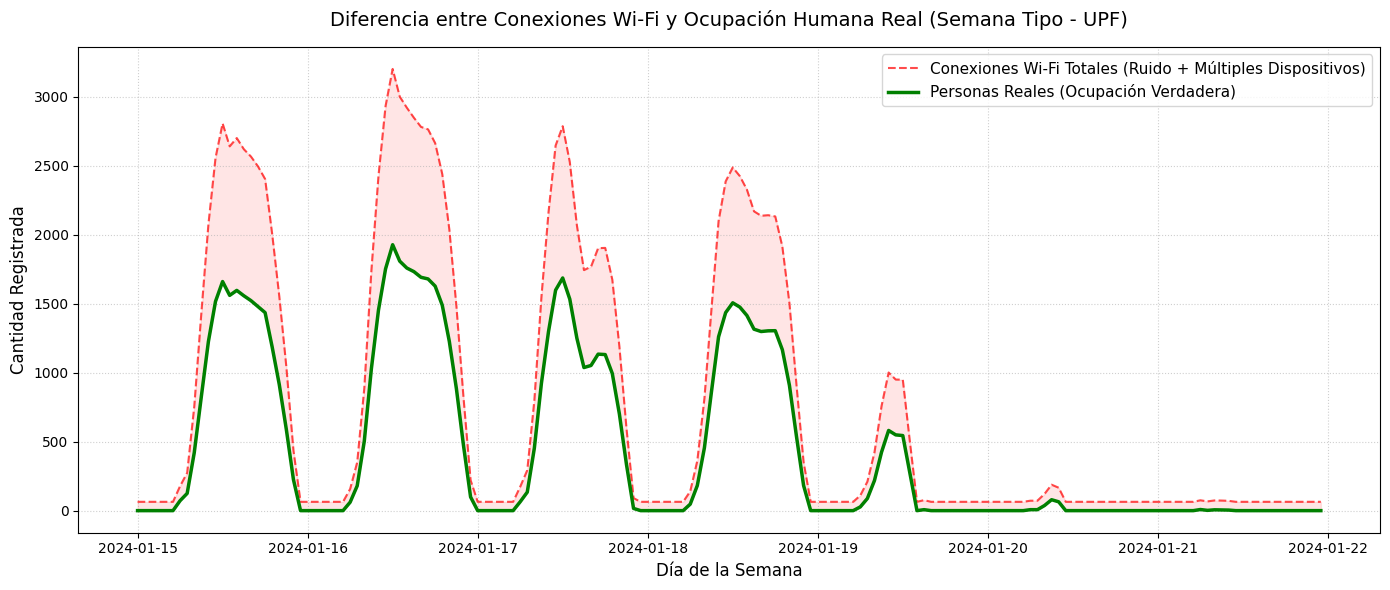

In [22]:
# Configuramos el lienzo de la gráfica
plt.figure(figsize=(14, 6))

# Dibujamos lo que reportaría el sistema Wi-Fi comercial
plt.plot(resumen_horario['Timestamp'], resumen_horario['Total_Dispositivos'], 
         label='Conexiones Wi-Fi Totales (Ruido + Múltiples Dispositivos)', 
         color='red', linestyle='--', alpha=0.7)

# Dibujamos la ocupación humana real
plt.plot(resumen_horario['Timestamp'], resumen_horario['Personas_Reales'], 
         label='Personas Reales (Ocupación Verdadera)', 
         color='green', linewidth=2.5)

# Detalles estéticos de la gráfica
plt.title('Diferencia entre Conexiones Wi-Fi y Ocupación Humana Real (Semana Tipo - UPF)', fontsize=14, pad=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Cantidad Registrada', fontsize=12)
plt.fill_between(resumen_horario['Timestamp'], resumen_horario['Total_Dispositivos'], resumen_horario['Personas_Reales'], color='red', alpha=0.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

# Mostrar la gráfica incrustada en el Notebook
plt.show()

## Integración del Calendario Académico 
Para hacer un análisis real del comportamiento universitario, vamos a descartar la división básica de laborable/festivo y vamos a cruzar nuestros datos con el calendario oficial de la UPF (`Calendari-UPF-2024.csv`). Esto nos permitirá ver el aforo medio de un día de "Classe" frente a un día de "Vacances" o "Avaluacio".

In [23]:
print("1. Cargando el calendario oficial de la UPF...")
df_calendario = pd.read_csv('../data/Calendari-UPF-2024.csv')

# Aseguramos el formato de la fecha del calendario
df_calendario['fecha'] = pd.to_datetime(df_calendario['fecha']).dt.date

# ¡LA SOLUCIÓN! Nos aseguramos de que el df principal tenga las columnas Fecha y Hora listas
df['Fecha'] = df['Timestamp'].dt.date
df['Hora'] = df['Timestamp'].dt.hour

print("2. Cruzando los datos (Haciendo el Merge)...")
# Ahora sí, cruzamos el dataframe principal (df) con el calendario
df = df.merge(df_calendario, left_on='Fecha', right_on='fecha', how='left')

# Borramos la columna 'fecha' duplicada y renombramos la otra para que quede profesional
df.drop(columns=['fecha'], inplace=True)
df.rename(columns={'tipus_dia': 'Tipo_Dia_UPF'}, inplace=True)

print("¡Cruce completado! Veamos cómo ha quedado:")
# Mostramos unas columnas para comprobar que al final pone "Vacances", "Classe", etc.
df[['Timestamp', 'ID_Universidad', 'Tipo_Dia_UPF']].head()

1. Cargando el calendario oficial de la UPF...
2. Cruzando los datos (Haciendo el Merge)...
¡Cruce completado! Veamos cómo ha quedado:


,Timestamp,ID_Universidad,Tipo_Dia_UPF
0,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances
1,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances
2,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances
3,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances
4,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances


In [24]:
print("1. Cargando el calendario oficial de la UPF...")
# Leemos el archivo que me has pasado en la imagen
df_calendario = pd.read_csv('../data/Calendari-UPF-2024.csv')

# Aseguramos que la columna fecha tenga formato de fecha exacto para poder cruzarla
df_calendario['fecha'] = pd.to_datetime(df_calendario['fecha']).dt.date

print("2. Cruzando los datos (Haciendo el Merge)...")
# Cruzamos el dataframe principal (df) con el calendario basándonos en la fecha
df = df.merge(df_calendario, left_on='Fecha', right_on='fecha', how='left')

# Borramos la columna 'fecha' del calendario porque ya tenemos 'Fecha', y renombramos la otra
df.drop(columns=['fecha'], inplace=True)
df.rename(columns={'tipus_dia': 'Tipo_Dia_UPF'}, inplace=True)

print("¡Cruce completado! Veamos cómo ha quedado:")
# Mostramos unas columnas para comprobar que al final pone "Vacances", "Classe", etc.
df[['Timestamp', 'ID_Universidad', 'Tipo_Dia_UPF']].head()

1. Cargando el calendario oficial de la UPF...
2. Cruzando los datos (Haciendo el Merge)...
¡Cruce completado! Veamos cómo ha quedado:


,Timestamp,ID_Universidad,Tipo_Dia_UPF,Tipo_Dia_UPF
0,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances,Vacances
1,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances,Vacances
2,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances,Vacances
3,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances,Vacances
4,2024-01-01 00:15:00,UPF_EQUIPAMIENTO,Vacances,Vacances


In [25]:
df = df.loc[:, ~df.columns.duplicated()]

In [26]:
print("Calculando el perfil promedio para cada Tipo de Día UPF...")

# Agrupamos por Fecha, Hora y el nuevo Tipo_Dia_UPF
resumen_diario_upf = df.groupby(['Fecha', 'Hora', 'Tipo_Dia_UPF']).agg(
    Personas_Reales=('ID_Universidad', lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique())
).reset_index()

# ¡LA SOLUCIÓN! Añadimos ['Personas_Reales'] justo antes del .mean() 
# para que no intente hacer medias matemáticas con las fechas.
perfil_upf = resumen_diario_upf.groupby(['Tipo_Dia_UPF', 'Hora'])['Personas_Reales'].mean().reset_index()

print("¡Listo para graficar!")

Calculando el perfil promedio para cada Tipo de Día UPF...
¡Listo para graficar!


### Curva de ocupación por día de la semana (solo días de clase)
Ahora vamos a extraer la curva promedio de cada día lectivo: lunes, martes, miércoles, jueves y viernes, usando únicamente los días del calendario que son `Classe`.

In [27]:
# Solo nos quedamos con los registros de días de clase según el calendario UPF
df_clase = df[df['Tipo_Dia_UPF'] == 'Classe'].copy()

df_clase['Dia_Semana'] = pd.to_datetime(df_clase['Fecha']).dt.weekday
weekday_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes'}

df_clase = df_clase[df_clase['Dia_Semana'].isin(weekday_map)]

dia_clase_resumen = df_clase.groupby(['Dia_Semana', 'Hora']).agg(
    Personas_Reales=('ID_Universidad', lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique())
).reset_index()

dia_clase_resumen['Dia_Nombre'] = dia_clase_resumen['Dia_Semana'].map(weekday_map)

perfil_clase_por_dia = dia_clase_resumen.groupby(['Dia_Nombre', 'Hora'])['Personas_Reales'].mean().reset_index()

print("Perfil de clase por día de la semana calculado correctamente.")

Perfil de clase por día de la semana calculado correctamente.


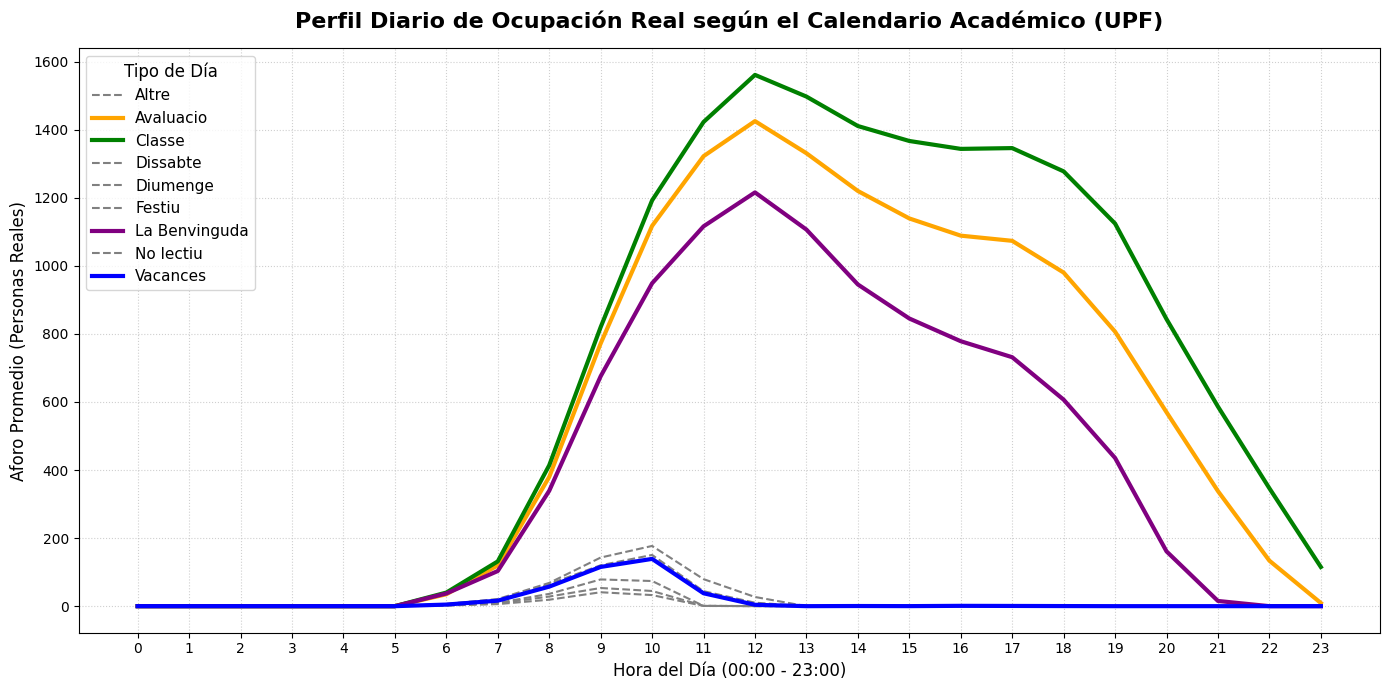

In [28]:
plt.figure(figsize=(14, 7))

# Sacamos la lista de todos los tipos de día que hay en tu CSV (Classe, Vacances, etc.)
tipos_de_dia = perfil_upf['Tipo_Dia_UPF'].unique()

# Le asignamos un estilo a las más importantes para que destaquen
colores = {'Classe': 'green', 'Avaluacio': 'orange', 'Vacances': 'blue', 'La Benvinguda': 'purple'}

# Dibujamos una línea por cada tipo de día
for tipo in tipos_de_dia:
    datos_tipo = perfil_upf[perfil_upf['Tipo_Dia_UPF'] == tipo]
    
    # Si el tipo está en nuestro diccionario de colores, lo pintamos fuerte; si no, gris suave (como festivos)
    color_linea = colores.get(tipo, 'grey')
    grosor = 3 if tipo in colores else 1.5
    estilo = '-' if tipo in colores else '--'
    
    plt.plot(datos_tipo['Hora'], datos_tipo['Personas_Reales'], 
             label=f'{tipo}', color=color_linea, linewidth=grosor, linestyle=estilo)

# Detalles estéticos
plt.title('Perfil Diario de Ocupación Real según el Calendario Académico (UPF)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Hora del Día (00:00 - 23:00)', fontsize=12)
plt.ylabel('Aforo Promedio (Personas Reales)', fontsize=12)
plt.xticks(range(0, 24, 1)) # Marcas hora a hora
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Tipo de Día', fontsize=11, title_fontsize=12, loc='upper left')
plt.tight_layout()

plt.show()

### Curvas diarias de ocupación en días de clase
Aquí graficamos las curvas promedio de ocupación real por hora para cada día lectivo: lunes a viernes.

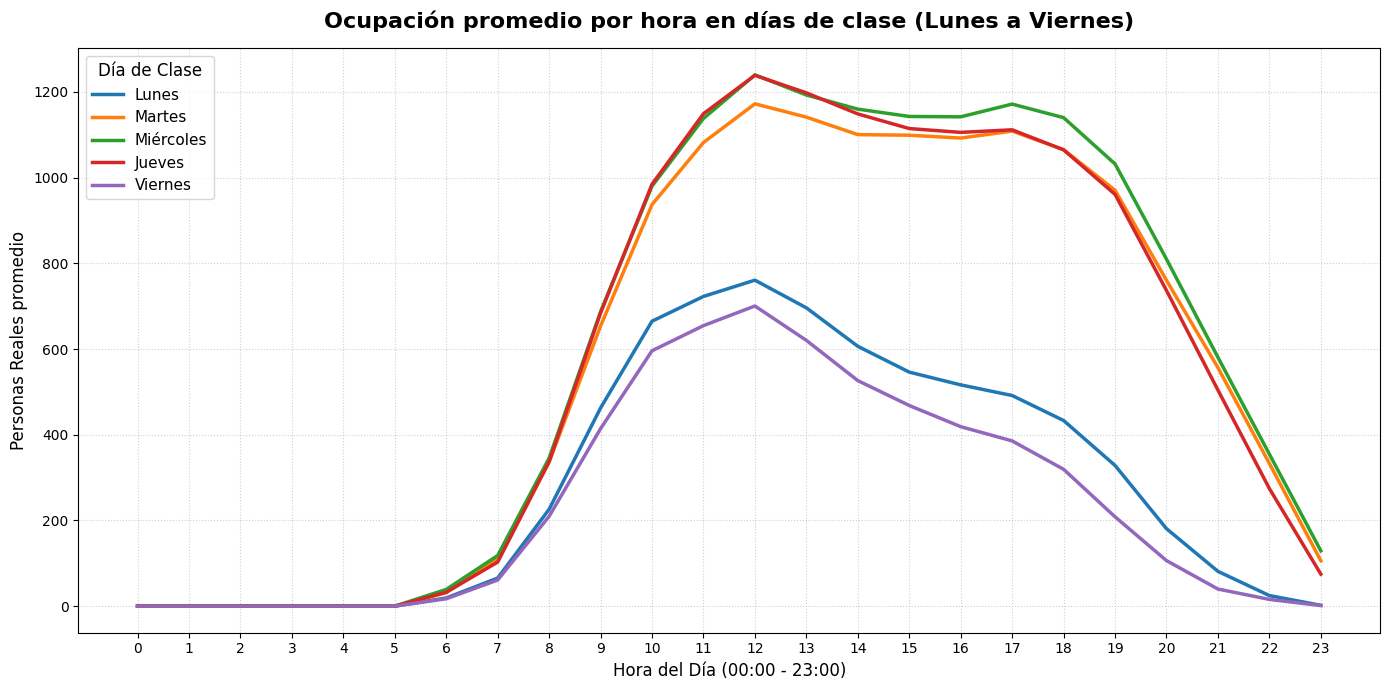

In [32]:
# ¡LA SOLUCIÓN! Creamos la columna que faltaba
df['Dia_de_la_Semana'] = df['Timestamp'].dt.dayofweek

# 1. El cálculo correcto (Promedio de promedios diarios)
# Usamos el lambda para descontar el ruido base de los ordenadores fijos
resumen_diario = df.groupby(['Fecha', 'Hora', 'Dia_de_la_Semana']).agg(
    Personas_Reales=('ID_Universidad', lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique())
).reset_index()

perfil_semanal = resumen_diario.groupby(['Dia_de_la_Semana', 'Hora'])['Personas_Reales'].mean().reset_index()

# 2. El "pegamento" para tu código de Matplotlib
mapa_dias = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
perfil_semanal['Dia_Nombre'] = perfil_semanal['Dia_de_la_Semana'].map(mapa_dias)

# Filtramos solo los días lectivos para pasárselos a tu código
perfil_clase_por_dia = perfil_semanal[perfil_semanal['Dia_Nombre'].isin(['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes'])]

# 3. AQUÍ VA TU CÓDIGO EXACTO DE MATPLOTLIB...
# plt.figure(figsize=(14, 7))
# ... (el resto de tu código para pintar la gráfica se queda igual)
plt.figure(figsize=(14, 7))

dias_clase = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes']
colores_dias = {'Lunes': '#1f77b4', 'Martes': '#ff7f0e', 'Miércoles': '#2ca02c', 'Jueves': '#d62728', 'Viernes': '#9467bd'}

for dia in dias_clase:
    datos_dia = perfil_clase_por_dia[perfil_clase_por_dia['Dia_Nombre'] == dia]
    if datos_dia.empty:
        continue
    plt.plot(datos_dia['Hora'], datos_dia['Personas_Reales'],
             label=dia, color=colores_dias[dia], linewidth=2.5)

plt.title('Ocupación promedio por hora en días de clase (Lunes a Viernes)', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Hora del Día (00:00 - 23:00)', fontsize=12)
plt.ylabel('Personas Reales promedio', fontsize=12)
plt.xticks(range(0, 24, 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Día de Clase', fontsize=11, title_fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
df_horario = df.resample('1h', on='Timestamp').agg(
    
    # Cuenta IDs de universidad únicos, ignorando impresoras/PCs fijos (la verdad)
    Personas_Reales=('ID_Universidad', lambda x: x[x != 'UPF_EQUIPAMIENTO'].nunique())
).reset_index()

print(df_horario.head(24)) # Para ver el primer día completo

             Timestamp  Personas_Reales
0  2024-01-01 00:00:00                0
1  2024-01-01 01:00:00                0
2  2024-01-01 02:00:00                0
3  2024-01-01 03:00:00                0
4  2024-01-01 04:00:00                0
5  2024-01-01 05:00:00                0
6  2024-01-01 06:00:00                0
7  2024-01-01 07:00:00                7
8  2024-01-01 08:00:00               91
9  2024-01-01 09:00:00              160
10 2024-01-01 10:00:00              243
11 2024-01-01 11:00:00              156
12 2024-01-01 12:00:00                6
13 2024-01-01 13:00:00                0
14 2024-01-01 14:00:00                0
15 2024-01-01 15:00:00                0
16 2024-01-01 16:00:00                0
17 2024-01-01 17:00:00                0
18 2024-01-01 18:00:00                0
19 2024-01-01 19:00:00                0
20 2024-01-01 20:00:00                0
21 2024-01-01 21:00:00                0
22 2024-01-01 22:00:00                0
23 2024-01-01 23:00:00                0


In [ ]:
df_horario.to_csv('../data/ocupacion_por_hora.csv', index=False)


: 